# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [2]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
# Load the prepared dataset from Phase 3
DATA_PATH = '../data/diabetic_data_cleaned.csv'

df = pd.read_csv(DATA_PATH)
print(f"Loaded prepared dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded prepared dataset: 101766 rows x 57 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,change,diabetesMed,readmitted,age_years,readmitted_30,change_flag,diabetesMed_flag,insulin_count,meglitinide_count,sulfonylurea_count
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,NO,5.0,0,0,0,0,0,0
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,Ch,Yes,>30,15.0,0,1,1,0,0,0
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,Yes,NO,25.0,0,0,1,0,0,0
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,Ch,Yes,NO,35.0,0,1,1,0,0,0
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,Ch,Yes,NO,45.0,0,1,1,0,0,0


---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your problem (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [4]:
# Select and document the modelling techniques used for 30-day readmission prediction.
modelling_techniques = {
    "problem_type": "Binary Classification",
    "target_variable": "readmitted_30",
    "candidate_models": [
        {
            "name": "Logistic Regression",
            "library": "sklearn.linear_model.LogisticRegression",
            "justification": "Baseline classifier for readmission risk with interpretable coefficients.",
            "assumptions": "Requires feature scaling and handles binary target well."
        },
        {
            "name": "Random Forest",
            "library": "sklearn.ensemble.RandomForestClassifier",
            "justification": "Robust to non-linear relationships and can handle mixed clinical features.",
            "assumptions": "Works well with noisy and structured healthcare data without extensive scaling."
        },
        {
            "name": "Gradient Boosting",
            "library": "sklearn.ensemble.GradientBoostingClassifier",
            "justification": "Often improves performance on imbalanced clinical datasets and fine-grained risk prediction.",
            "assumptions": "Requires careful tuning of learning rate and tree depth."
        }
    ]
}

print(f"Problem Type: {modelling_techniques['problem_type']}")
print(f"Target Variable: {modelling_techniques['target_variable']}")
print("\nCandidate Models:")
for i, model in enumerate(modelling_techniques['candidate_models'], 1):
    print(f"  {i}. {model['name']} — {model['justification']}")

Problem Type: Binary Classification
Target Variable: readmitted_30

Candidate Models:
  1. Logistic Regression — Baseline classifier for readmission risk with interpretable coefficients.
  2. Random Forest — Robust to non-linear relationships and can handle mixed clinical features.
  3. Gradient Boosting — Often improves performance on imbalanced clinical datasets and fine-grained risk prediction.


In [5]:
# Import the specific model classes used for readmission prediction
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [6]:
# Define the test design and split the data for readmission modelling.

RANDOM_SEED = 42
TEST_SIZE = 0.2  # Use 20% of the data for testing

TARGET_COL = 'readmitted_30'
feature_cols = [
    'age_years', 'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient',
    'number_diagnoses', 'change_flag', 'diabetesMed_flag'
]
feature_cols += [col for col in df.columns if col.endswith('_count')]
feature_cols = [col for col in feature_cols if col in df.columns]

X = df[feature_cols]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Features used: {len(feature_cols)}")

Training set: 81412 samples
Test set:     20354 samples
Features used: 14


In [9]:
# Document and justify the test design for readmission risk modelling
test_design = {
    "split_ratio": f"{int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)}",
    "validation_strategy": "Hold-out test set with 5-fold cross-validation for model validation",
    "stratified": True,
    "random_seed": RANDOM_SEED,
    "justification": "Stratified split maintains class balance between training and test sets, which is crucial for imbalanced readmission data. Cross-validation provides robust performance estimates."
}
print("\nTest Design:")
for key, value in test_design.items():
    print(f"  {key}: {value}")


Test Design:
  split_ratio: 80/20
  validation_strategy: Hold-out test set with 5-fold cross-validation for model validation
  stratified: True
  random_seed: 42
  justification: Stratified split maintains class balance between training and test sets, which is crucial for imbalanced readmission data. Cross-validation provides robust performance estimates.


---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

In [10]:
# Build and train candidate models for 30-day readmission prediction.
# Store trained models in a dictionary for easy comparison.

trained_models = {}

# --- Model 1: Logistic Regression ---
model_1 = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, solver='lbfgs')
model_1.fit(X_train, y_train)
trained_models['Logistic Regression'] = model_1

# --- Model 2: Random Forest ---
model_2 = RandomForestClassifier(random_state=RANDOM_SEED, n_estimators=100, max_depth=15, n_jobs=-1)
model_2.fit(X_train, y_train)
trained_models['Random Forest'] = model_2

# --- Model 3: Gradient Boosting ---
model_3 = GradientBoostingClassifier(random_state=RANDOM_SEED, n_estimators=100, learning_rate=0.1, max_depth=5)
model_3.fit(X_train, y_train)
trained_models['Gradient Boosting'] = model_3

print(f"Successfully trained {len(trained_models)} model(s).")

Successfully trained 3 model(s).


In [11]:
# Hyperparameter tuning with GridSearchCV for Random Forest model

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10, 15]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC score: {grid_search.best_score_:.4f}")

trained_models['Random Forest (Tuned)'] = grid_search.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'max_depth': 10, 'min_samples_split': 15, 'n_estimators': 100}
Best CV ROC-AUC score: 0.6358


---
### Task 4: Assess Model

Interpret and compare the results of your trained models. Assessment should consider:

- **Performance Metrics:** Evaluate each model using the success metrics defined in Phase 1 (e.g., accuracy, F1-score, RMSE, AUC-ROC).
- **Cross-Validation:** Use cross-validation scores to understand variance and reliability.
- **Comparison Table:** Create a summary table ranking all models side by side.
- **Confusion Matrix / Error Analysis:** Visualise where the model succeeds and fails.
- **Model Selection:** Select the best-performing model based on the combined assessment.

**Instructions:** Evaluate all trained models, compare them, and select the best one.

In [12]:
# Evaluate and compare all trained models for 30-day readmission prediction.
# Build a comprehensive results summary table.

from sklearn.metrics import roc_auc_score

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results).set_index('Model')
print("\n" + "=" * 80)
print("MODEL COMPARISON: 30-Day Readmission Risk Prediction")
print("=" * 80)
print(results_df.round(4))
print("=" * 80)


MODEL COMPARISON: 30-Day Readmission Risk Prediction
                       Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                
Logistic Regression      0.8884     0.8453  0.8884    0.8388   0.6422
Random Forest            0.8886     0.8512  0.8886    0.8382   0.6390
Gradient Boosting        0.8886     0.8493  0.8886    0.8385   0.6479
Random Forest (Tuned)    0.8884     0.8453  0.8884    0.8366   0.6464



BEST MODEL: Gradient Boosting
                     precision    recall  f1-score   support

     No Readmission       0.89      1.00      0.94     18083
Readmitted <30 days       0.53      0.01      0.02      2271

           accuracy                           0.89     20354
          macro avg       0.71      0.51      0.48     20354
       weighted avg       0.85      0.89      0.84     20354



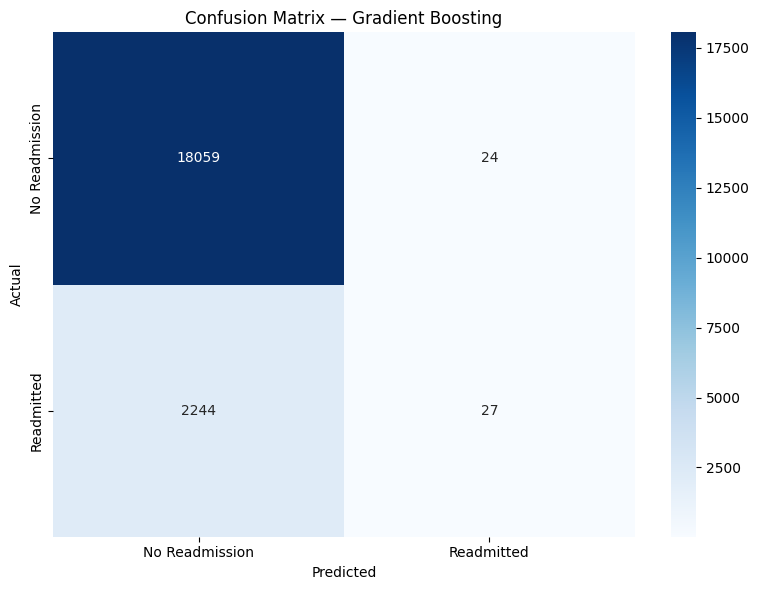

In [13]:
# Visualize results: Confusion Matrix and classification report for the best model.

# Select best model based on ROC-AUC (primary success metric for readmission risk)
best_model_name = results_df['ROC-AUC'].idxmax()
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"\n{'='*80}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*80}")
print(classification_report(y_test, y_pred_best, target_names=['No Readmission', 'Readmitted <30 days']))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=['No Readmission', 'Readmitted'],
            yticklabels=['No Readmission', 'Readmitted'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

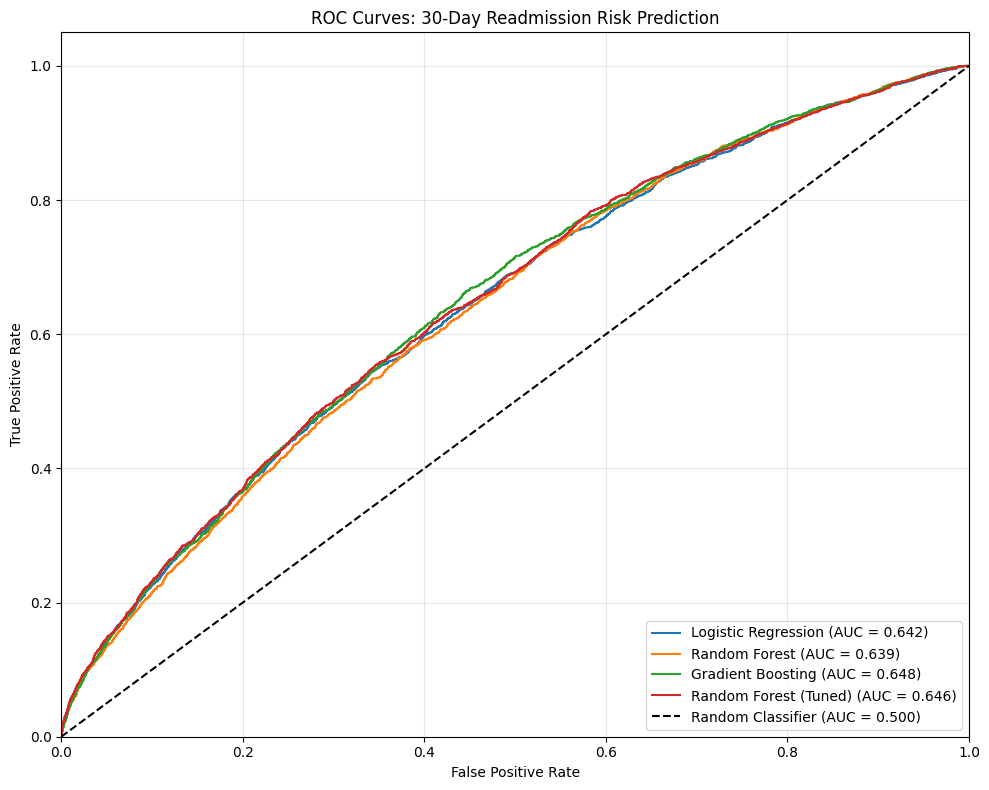


CROSS-VALIDATION ANALYSIS: Gradient Boosting
Cross-Validation ROC-AUC Scores: [0.64   0.6294 0.6279 0.6399 0.6327]
Mean ROC-AUC: 0.6340 (+/- 0.0051)

Cross-Validation F1 Scores: [0.838  0.8382 0.8379 0.8376 0.8376]
Mean F1: 0.8379 (+/- 0.0002)


In [16]:
# Plot ROC curves for all models to visualize AUC performance

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for name, model in trained_models.items():
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: 30-Day Readmission Risk Prediction')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cross-validation for the selected best model using ROC-AUC metric

print(f"\n{'='*80}")
print(f"CROSS-VALIDATION ANALYSIS: {best_model_name}")
print(f"{'='*80}")

cv_scores_auc = cross_val_score(best_model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
print(f"Cross-Validation ROC-AUC Scores: {cv_scores_auc.round(4)}")
print(f"Mean ROC-AUC: {cv_scores_auc.mean():.4f} (+/- {cv_scores_auc.std():.4f})")

cv_scores_f1 = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
print(f"\nCross-Validation F1 Scores: {cv_scores_f1.round(4)}")
print(f"Mean F1: {cv_scores_f1.mean():.4f} (+/- {cv_scores_f1.std():.4f})")
print(f"{'='*80}")
